In [2]:
import pandas as pd

df = pd.read_csv("../data/clean/clean_data.csv")

df.head()

,year,quarter,quarter_end_month,quarter_end_date,vic_ytd_enrolments,vic_ytd_commencements,estimated_melbourne_vacancies,estimated_melbourne_vacancy_rate_pct,student_geography,vacancy_geography,notes,quarter_num,quarter_end_month_num
0,2020,Q1,Mar,2020-03-31,216681,56991,3000,4.4,VIC,Melbourne,Quarter-end YTD student data; vacancy is chart...,1,3
1,2020,Q2,Jun,2020-06-30,235433,75743,6200,8.0,VIC,Melbourne,Quarter-end YTD student data; vacancy is chart...,2,6
2,2020,Q3,Sep,2020-09-30,267172,107482,8100,10.3,VIC,Melbourne,Quarter-end YTD student data; vacancy is chart...,3,9
3,2020,Q4,Dec,2020-12-31,282720,123030,7800,9.9,VIC,Melbourne,Quarter-end YTD student data; vacancy is chart...,4,12
4,2021,Q1,Mar,2021-03-31,178296,37476,6700,8.5,VIC,Melbourne,Quarter-end YTD student data; vacancy is chart...,1,3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   year                                  24 non-null     int64  
 1   quarter                               24 non-null     str    
 2   quarter_end_month                     24 non-null     str    
 3   quarter_end_date                      24 non-null     str    
 4   vic_ytd_enrolments                    24 non-null     int64  
 5   vic_ytd_commencements                 24 non-null     int64  
 6   estimated_melbourne_vacancies         24 non-null     int64  
 7   estimated_melbourne_vacancy_rate_pct  24 non-null     float64
 8   student_geography                     24 non-null     str    
 9   vacancy_geography                     24 non-null     str    
 10  notes                                 24 non-null     str    
 11  quarter_num                     

In [4]:
df.describe()

,year,vic_ytd_enrolments,vic_ytd_commencements,estimated_melbourne_vacancies,estimated_melbourne_vacancy_rate_pct,quarter_num,quarter_end_month_num
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.00000,24.000000
mean,2022.500000,237502.416667,93522.250000,2916.666667,3.791667,2.50000,7.500000
std,1.744557,49660.709950,39799.040087,2302.865260,2.901262,1.14208,3.426241
min,2020.000000,146792.000000,37476.000000,800.000000,1.100000,1.00000,3.000000
25%,2021.000000,204511.750000,59133.250000,1500.000000,2.000000,1.75000,5.250000
50%,2022.500000,231081.500000,84843.000000,1700.000000,2.250000,2.50000,7.500000
75%,2024.000000,271059.000000,123930.000000,3975.000000,5.075000,3.25000,9.750000
max,2025.000000,327815.000000,171667.000000,8100.000000,10.300000,4.00000,12.000000


The updated dataset contains quarterly observations from 2020 Q1 to 2025 Q4. The main variables are Victoria year-to-date international student enrolments, Victoria year-to-date international student commencements, estimated Melbourne rental vacancies, and estimated Melbourne rental vacancy rates.

The dataset has more observations than the original annual dataset, which improves the scope for exploratory analysis. The data types are appropriate: year is numeric, quarter is categorical, and the student and vacancy variables are numeric.

The main limitation is that the international student variables are measured at the Victoria level, while the vacancy variables refer to Melbourne. In addition, the vacancy values are approximated from SQM public charts rather than downloaded from the underlying paid data table. Therefore, the analysis should be interpreted as descriptive and exploratory.

In [5]:
import matplotlib.pyplot as plt

df["quarter_end_date"] = pd.to_datetime(df["quarter_end_date"])

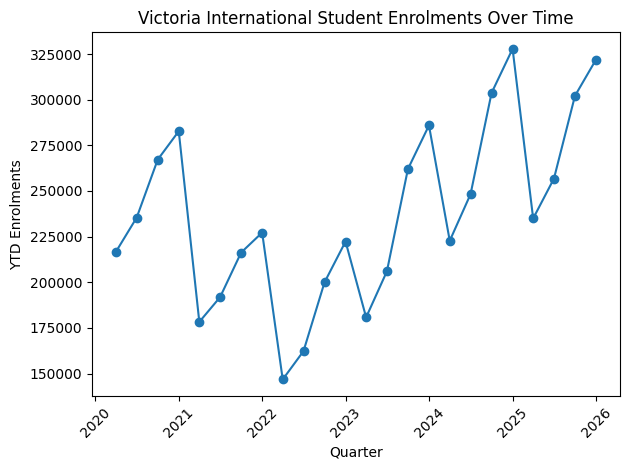

In [6]:
plt.plot(df["quarter_end_date"], df["vic_ytd_enrolments"], marker="o")
plt.title("Victoria International Student Enrolments Over Time")
plt.xlabel("Quarter")
plt.ylabel("YTD Enrolments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

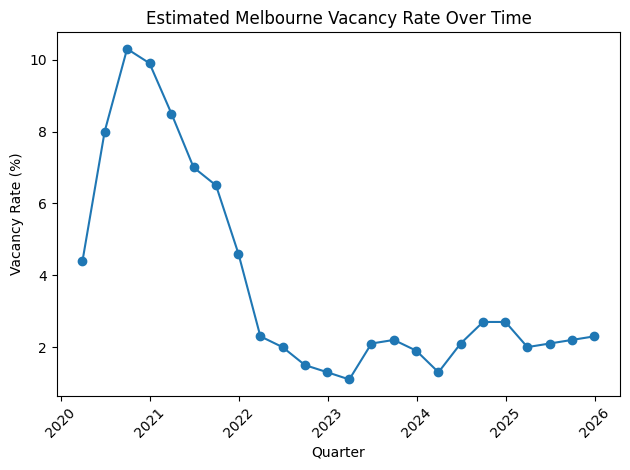

In [7]:
plt.plot(df["quarter_end_date"], df["estimated_melbourne_vacancy_rate_pct"], marker="o")
plt.title("Estimated Melbourne Vacancy Rate Over Time")
plt.xlabel("Quarter")
plt.ylabel("Vacancy Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

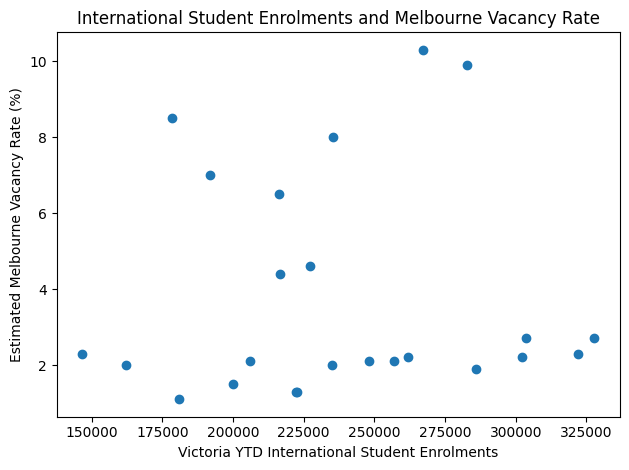

In [8]:
plt.scatter(df["vic_ytd_enrolments"], df["estimated_melbourne_vacancy_rate_pct"])
plt.title("International Student Enrolments and Melbourne Vacancy Rate")
plt.xlabel("Victoria YTD International Student Enrolments")
plt.ylabel("Estimated Melbourne Vacancy Rate (%)")
plt.tight_layout()
plt.show()

In [9]:
df[["vic_ytd_enrolments", "estimated_melbourne_vacancy_rate_pct"]].corr()

,vic_ytd_enrolments,estimated_melbourne_vacancy_rate_pct
vic_ytd_enrolments,1.000000,0.005179
estimated_melbourne_vacancy_rate_pct,0.005179,1.000000


The scatter plot does not show a clear linear relationship between Victoria international student enrolments and the estimated Melbourne vacancy rate. Some quarters with relatively low or mid-level student enrolments have very high vacancy rates, especially during the COVID-affected period, while many later quarters have low vacancy rates despite higher student enrolments.

The correlation coefficient is approximately 0.005, which is very close to zero. This suggests that there is almost no contemporaneous linear correlation between the two variables in this quarterly sample. Therefore, the EDA does not provide strong first-order evidence of a simple negative relationship between international student enrolments and vacancy rates.

This does not necessarily mean that international students are unrelated to rental-market conditions. The relationship may be affected by COVID disruptions, geographic mismatch between Victoria-level student data and Melbourne-level vacancy data, lagged rental-market responses, housing supply, domestic migration, and broader economic conditions.

Overall, the updated quarterly dataset provides more observations than the original annual dataset, but the simple contemporaneous relationship between student enrolments and vacancy rates is weak. Future analysis may need to consider lagged student variables, alternative housing-market outcomes, or more geographically matched data.